# Setup

In [129]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import os

In [130]:
import logging
import sys
sys.path.append("../")

from utils.seed_all import seed_all
from metrics.factory import MetricsFactory

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

In [131]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

In [132]:
def load_data(base_file):
    with open(f'{base_file}/config.yaml', "r") as f:
        config = yaml.safe_load(f)
    path = f'{base_file}/train_labels_predictions.pt'
    cache = torch.load(path, weights_only=False)
    y_true, y_out = cache['y_true'], cache['y_scores']
    y_pred, y_scores = y_out
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    y_true['scores'] = y_scores.mean(axis=(1, 2))

    return y_true, y_pred, y_scores, config

In [133]:
def get_window_metrics(base_path):
    windows = {}

    runs = [f for f in os.listdir(base_path)]
    for run in runs:
        run_path = f'{base_path}/{run}'
        print(run_path)

        if not os.path.exists(f'{run_path}/train_labels_predictions.pt'):
            continue

        try:
            with open(f'{run_path}/config.yaml', "r") as f:
                config = yaml.safe_load(f)
            path = f'{run_path}/train_labels_predictions.pt'
            cache = torch.load(path, weights_only=False)
            y_true, y_out = cache['y_true'], cache['y_scores']
            y_pred, y_scores = y_out
            y_pred = np.array(y_pred)
            y_scores = np.array(y_scores)
            y_true['scores'] = y_scores.mean(axis=(1, 2))

            y_true_benign = y_true[y_true["label"] == 'Normal']
            mean = y_true_benign["scores"].mean()
            std = y_true_benign["scores"].std()
            windows[config['pre_processing']['window_size']] = {'mean': mean, 'std': std}
        except:
            continue

    return windows

In [134]:
def density_function(y_true_benign, quantile=0.9999, threshold=None):
    if not threshold:
        threshold = y_true_benign["scores"].quantile(quantile)

    # Calculate mean and std
    mean = y_true_benign["scores"].mean()
    std = y_true_benign["scores"].std()

    # Plot histogram + KDE
    # y_true_benign["scores"].plot(kind="hist", bins=20, density=True, alpha=0.6, edgecolor="black")
    y_true_benign["scores"].plot(kind="kde")

    # Add mean line
    plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")

    # Add ±1 std lines
    plt.axvline(mean - std, color="blue", linestyle=":", linewidth=2, label=f"-1 Std = {mean-std:.2f}")
    plt.axvline(mean + std, color="blue", linestyle=":", linewidth=2, label=f"+1 Std = {mean+std:.2f}")
    plt.axvline(threshold, color="yellow", linestyle=":", linewidth=2, label=f"Quantile={quantile}")

    plt.xlabel("Scores")
    plt.title("Scores Distribution with Mean & Std")
    plt.legend()
    plt.show()

In [135]:
def plot_line(y_pred, y_true=None, name="True vs Predicted values"):
    plt.figure(figsize=(12, 6))

    # Plot true values
    if y_true is not None:
        x_true = np.arange(len(y_true))
        plt.plot(x_true, y_true, marker='x', label="True values", color="red")

        # Align predictions to the *end* of true series
        start_idx = len(y_true) - len(y_pred)
        x_pred = np.arange(start_idx, start_idx + len(y_pred))
    else:
        # If no y_true, just start from 0
        x_pred = np.arange(len(y_pred))
    plt.plot(x_pred, y_pred, marker='o', label="Prediction values", color="blue")

    # Labels, title, legend
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(name)
    plt.legend()
    plt.grid(True)
    plt.show()

# Base config

In [152]:
y_true_sub, y_pred_sub, y_scores_sub, config_sub = load_data('../runs/tcn_pred_TOWIDS_20251203_191830')
y_true_benign_sub = y_true_sub[y_true_sub["label"] == 'Normal']

In [153]:
y_true, y_pred, y_scores, config = load_data('../runs/tcn_pred_TOWIDS_20251203_191830')
y_true_benign = y_true[y_true["label"] == 'Normal']

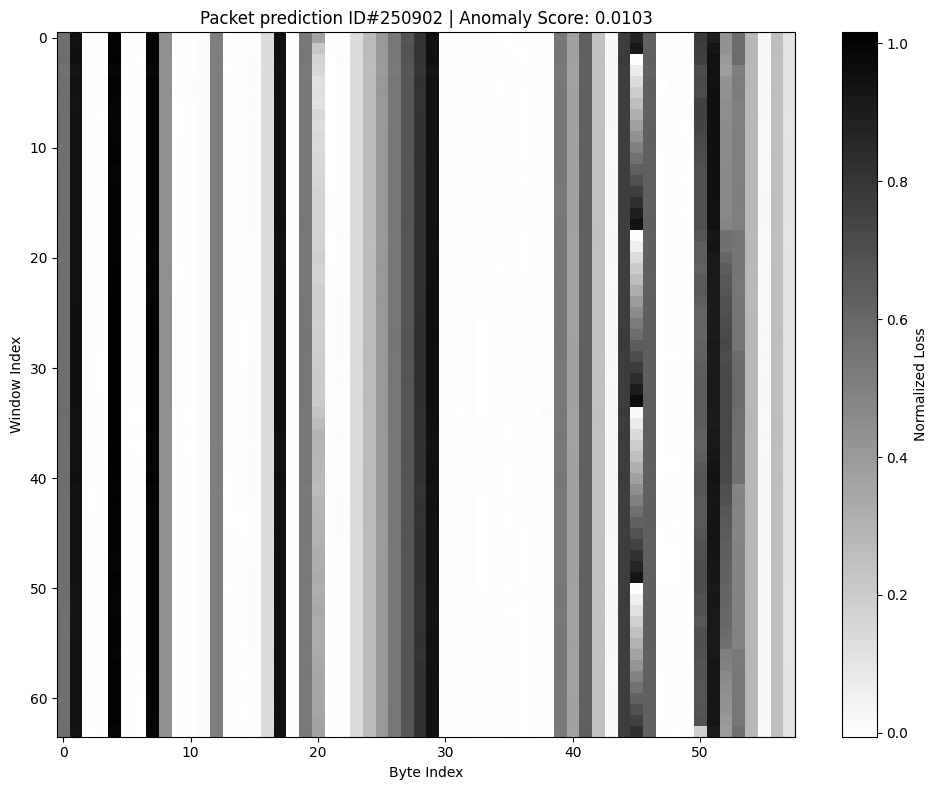

In [33]:
idx = y_true_benign.index[2]
plot_img_loss(y_pred[idx], name=f'Packet prediction ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

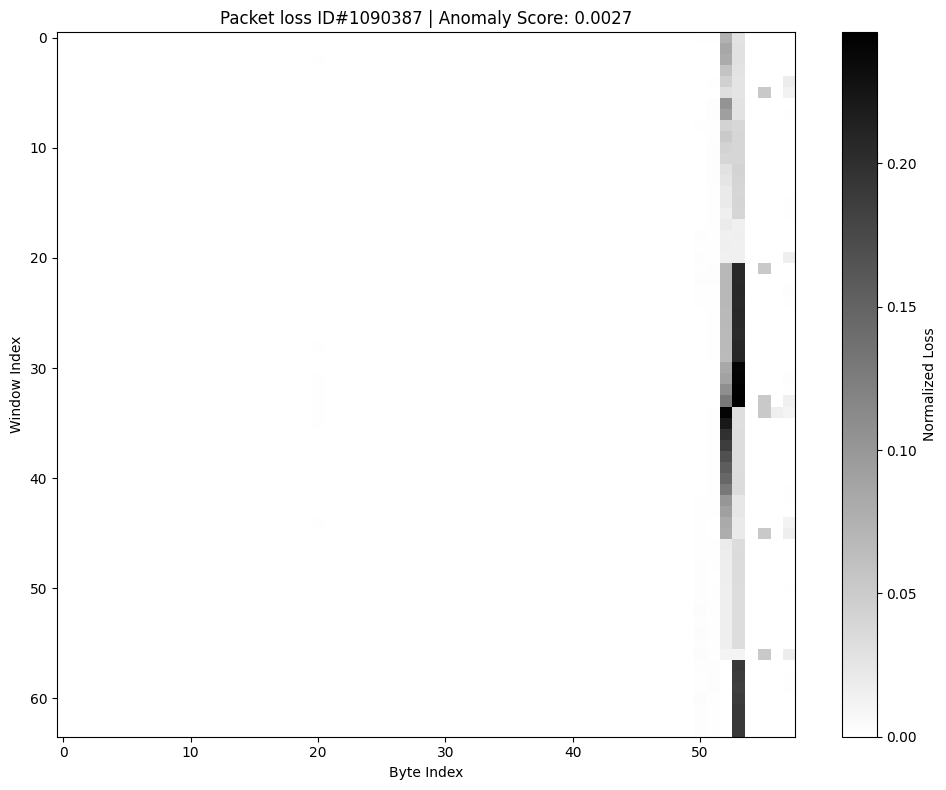

In [34]:
idx = y_true_benign.index[0]
plot_img_loss(y_scores[idx], name=f'Packet loss ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

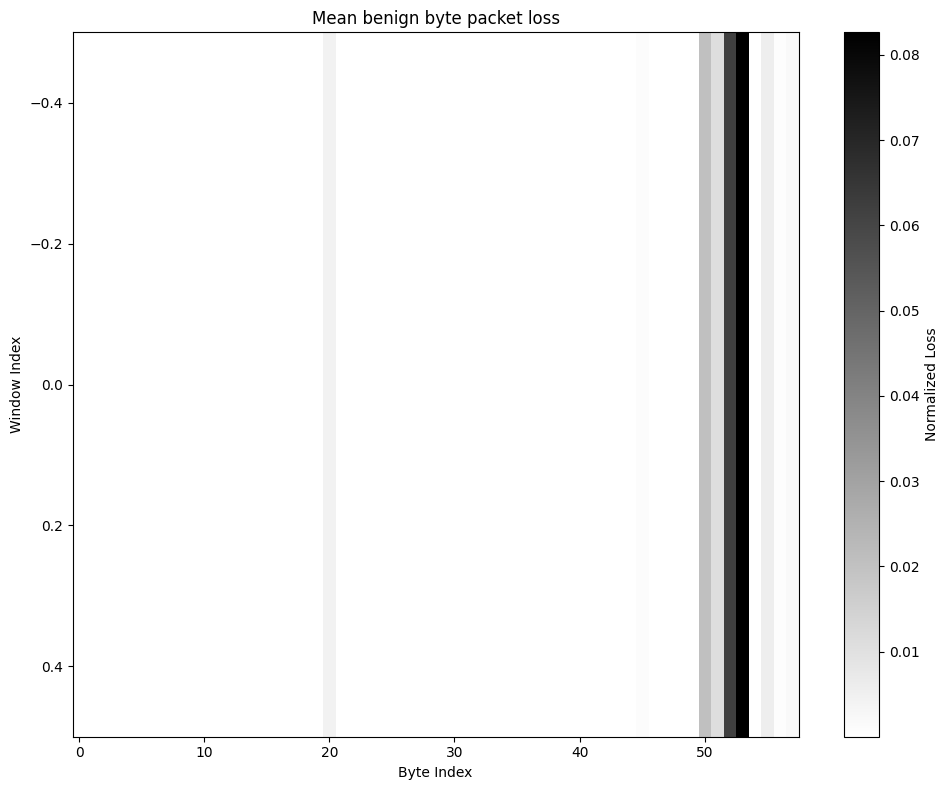

In [35]:
plot_img_loss(np.expand_dims(y_scores[y_true['label'] == 'Normal'].mean(1).mean(0), axis=0), name=f'Mean benign byte packet loss')

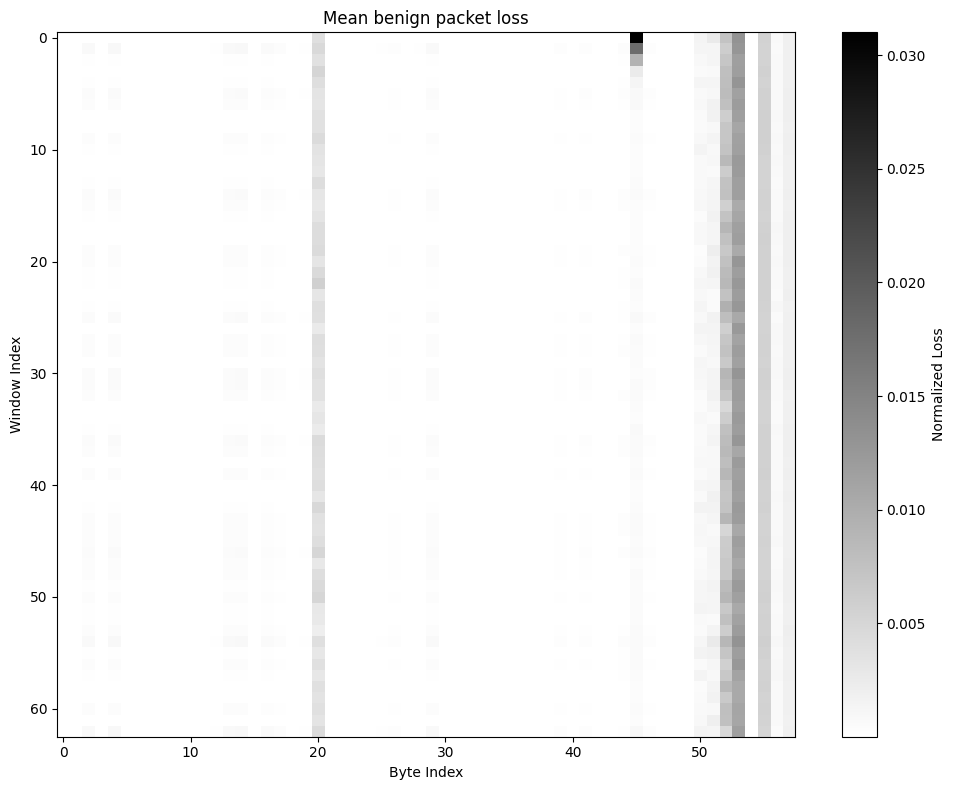

In [298]:
plot_img_loss(y_scores[y_true['label'] == 'Normal'].mean(0), name=f'Mean benign packet loss')

In [14]:
def get_threshold_table(y_true_benign):
    ts = [0.95, 0.98, 0.99, 0.999, 0.9999]
    r = {}
    for t in ts:
        threshold = y_true_benign["scores"].quantile(t)
        fp = y_true_benign[y_true_benign["scores"] > threshold]
        r[t] = {
            'count': len(fp),
            'mean': fp['scores'].mean(),
            'std': fp['scores'].std(),
            # 'fp': fp
        }
    return r

In [15]:
t_results = get_threshold_table(y_true_benign)

In [16]:
pd.DataFrame(t_results)

,0.9500,0.9800,0.9900,0.9990,0.9999
count,224.000000,90.000000,45.000000,5.000000,1.000000
mean,0.009375,0.011057,0.012065,0.014885,0.015778
std,0.001739,0.001426,0.001388,0.000742,NaN


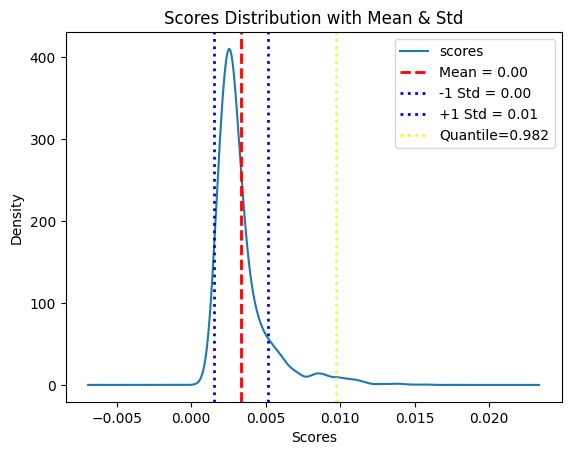

In [17]:
density_function(y_true_benign, quantile=0.982)

In [ ]:
q = 0.982
threshold = y_true_benign["scores"].quantile(q)
fp = y_true_benign[y_true_benign["scores"] > threshold]

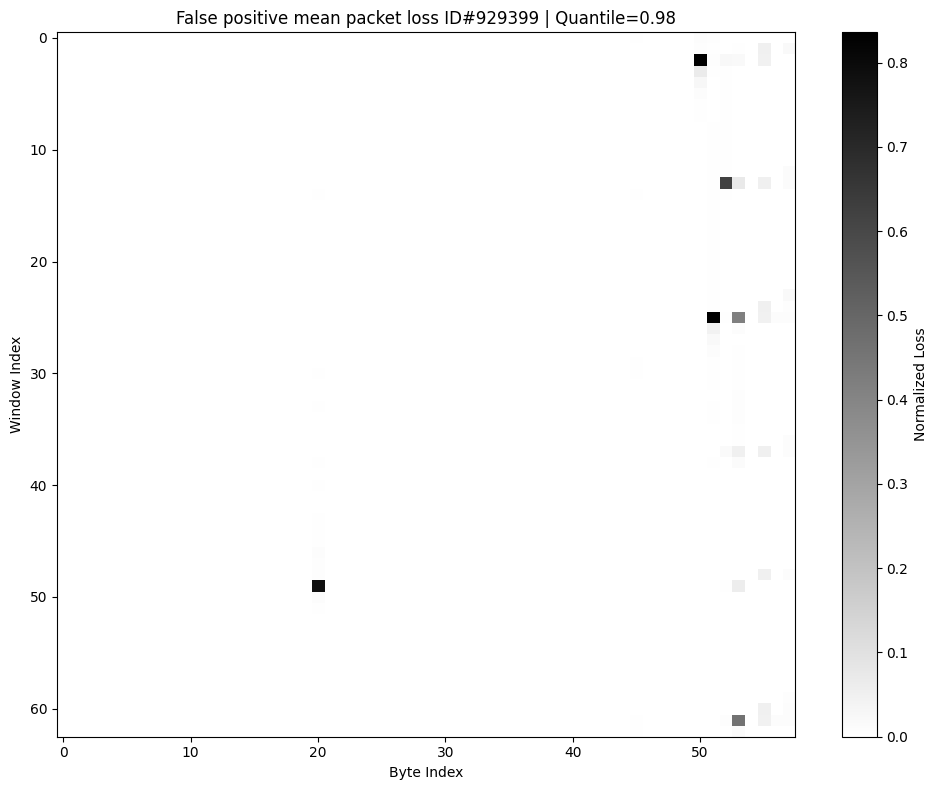

In [304]:
idx = fp.index[1]
plot_img_loss(y_scores[idx], name=f'False positive mean packet loss ID#{y_true['start_idx'].iloc[idx]} | Quantile={q}')

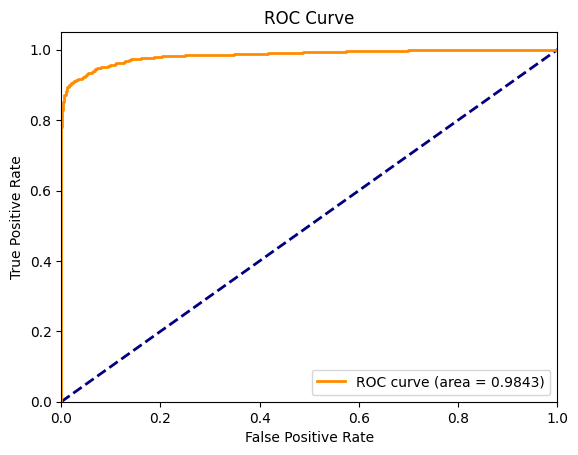

In [155]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_scores.mean((1, 2)))
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_scores.mean((1, 2)))
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [156]:
df_t = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'youden_index': tpr - fpr})

In [157]:
youden_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[youden_index]

In [158]:
optimal_threshold

np.float32(0.0003102615)

In [159]:
y_true[y_true['start_idx'] <= 11590].sort_values('start_idx', ascending=False)

,label,start_idx,desc_windows,scores
4160,Normal,11468,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000213
1657,Normal,11360,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000214
2708,Normal,11125,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000189
199,Normal,11117,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000186
4827,Normal,11099,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000177
...,...,...,...,...
4431,Normal,689,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000208
4998,Normal,667,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000196
237,Normal,379,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000204
2048,Normal,268,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000221


In [160]:
y_true[(y_true['scores'] > optimal_threshold) & (y_true['label'] == 'Normal')].sort_values('start_idx')

,label,start_idx,desc_windows,scores
2336,Normal,29113,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000350
2342,Normal,29174,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000351
4277,Normal,43846,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000319
5392,Normal,114269,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000336
2294,Normal,135840,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000332
...,...,...,...,...
2344,Normal,1152598,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000321
2744,Normal,1152763,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000328
4183,Normal,1152769,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000326
2771,Normal,1168078,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.000314


In [162]:
fp_idx = y_true[(y_true['scores'] > optimal_threshold) & (y_true['label'] == 'Normal')].index

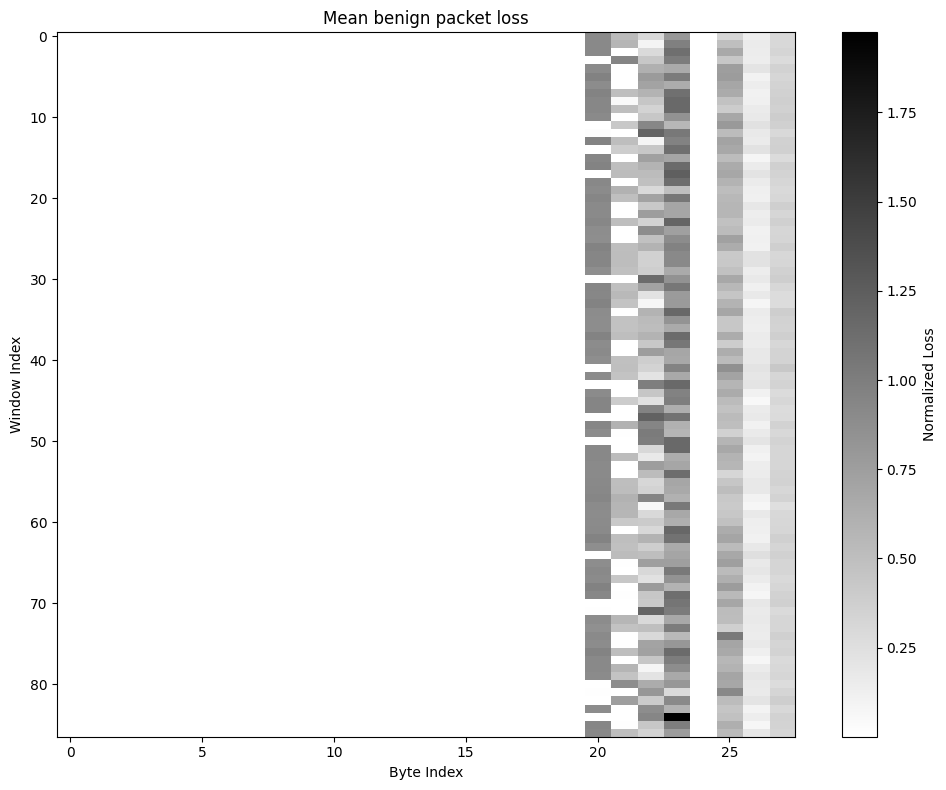

In [169]:
plot_img_loss(y_scores[fp_idx].sum(1)[:, 30:], name=f'Mean benign packet loss')

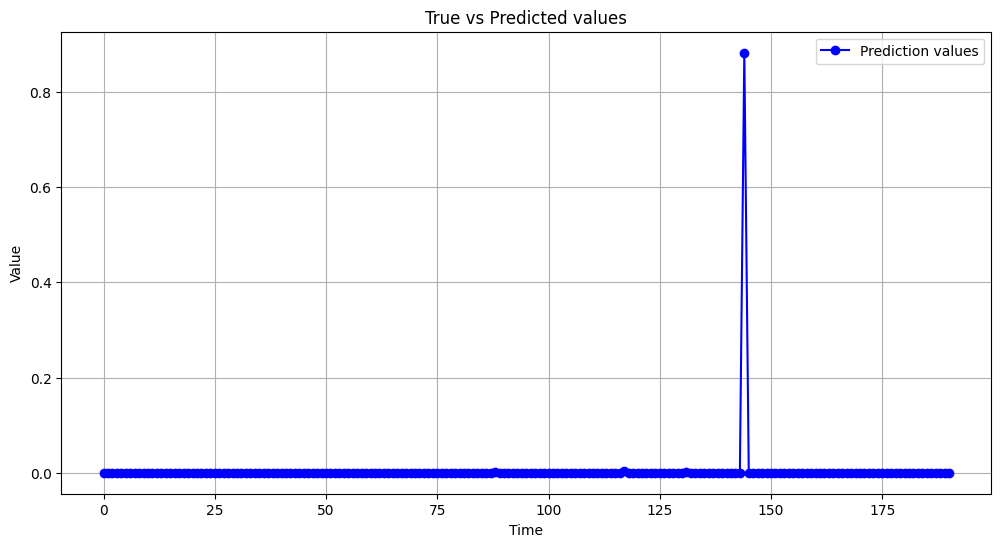

In [94]:
plot_line(y_scores[7, :, 50])

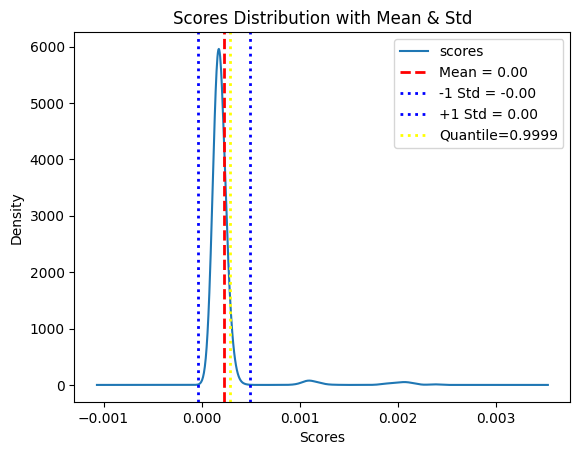

In [55]:
density_function(y_true[y_true['label'] == 'Normal'], threshold=optimal_threshold)

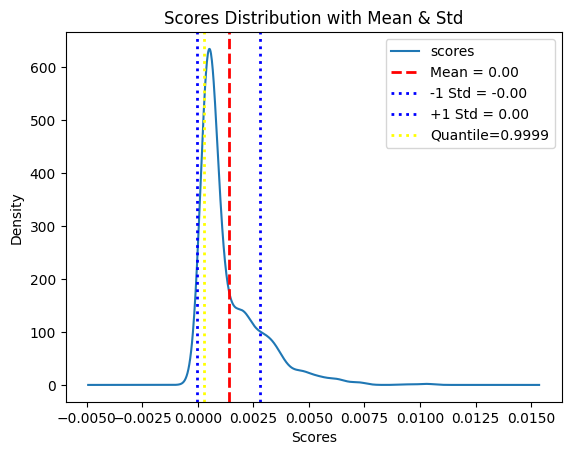

In [56]:
density_function(y_true[y_true['label'] != 'Normal'], threshold=optimal_threshold)

In [306]:
metrics_handler = MetricsFactory().get({'metrics': {'name': 'anomaly_detector', 'quantile': q }}, logger)
metrics = metrics_handler.get_overall_metrics(y_true, (y_pred, y_scores))

2025-09-19 15:37:24,330 | INFO | Metrics 
{
    "AUCROC": 0.6732859377975521,
    "Accuracy": 0.8191952621494513,
    "TPR": 0.22945484133441824,
    "FPR": 0.020168439716312058,
    "Precision": 0.7560321715817694,
    "F1-score": 0.352059925093633,
    "optimal_threshold": 0.001357146184891461,
    "mean": 0.0006442113080993295,
    "std": 0.00045702766510657966,
    "tpr_per_attack": {
        "Frame Injection": 0.22945484133441824
    },
    "aucroc_per_attack": {
        "Frame Injection": 0.6732859377975521
    }
}
2025-09-19 15:37:24,330 | INFO | Metrics 
{
    "AUCROC": 0.6732859377975521,
    "Accuracy": 0.8191952621494513,
    "TPR": 0.22945484133441824,
    "FPR": 0.020168439716312058,
    "Precision": 0.7560321715817694,
    "F1-score": 0.352059925093633,
    "optimal_threshold": 0.001357146184891461,
    "mean": 0.0006442113080993295,
    "std": 0.00045702766510657966,
    "tpr_per_attack": {
        "Frame Injection": 0.22945484133441824
    },
    "aucroc_per_attack": {


# OLD

In [69]:
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(y_true_benign_192['scores'].to_numpy(), y_true_benign_32['scores'].to_numpy())
print("KS test statistic:", stat)
print("p-value:", p_value)

KS test statistic: 0.9991120976692563
p-value: 0.0


In [70]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(y_true_benign_192['scores'].to_numpy(), y_true_benign_32['scores'].to_numpy())
print("Mann-Whitney U test statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U test statistic: 18824.0
p-value: 0.0


In [38]:
pd.DataFrame(windows)

,192,128,64,32,16,8,4,256,2
mean,1.041347e-07,5.142936e-07,1.877565e-07,5.361443e-07,4.666428e-07,0.000060,0.000367,1.961870e-07,0.000097
std,2.160101e-06,2.799480e-06,4.762130e-06,2.330366e-07,4.289506e-07,0.000114,0.001270,2.557852e-06,0.000317


In [74]:
y_true.head()

,label,start_idx,desc_windows,scores
0,Frame Injection,831090,"[Frame Injection, Frame Injection, Frame Injec...",6.126118e-05
1,Frame Injection,819979,"[Frame Injection, Frame Injection, Frame Injec...",2.164331e-08
2,Normal,4850,"[Normal, Normal, Normal, Normal, Normal, Norma...",3.269571e-07
3,Frame Injection,891142,"[Frame Injection, Frame Injection, Frame Injec...",9.690701e-08
4,Frame Injection,825359,"[Normal, Normal, Normal, Normal, Normal, Norma...",5.187680e-05


In [81]:
fn = y_true[(y_true['scores'] < 1.2369906698950217e-06) & (y_true['label'] != 'Normal')].index
tp = y_true[(y_true['scores'] >= 1.2369906698950217e-06) & (y_true['label'] != 'Normal')].index

In [92]:
desc_windows_fn = np.array([[j == 'Normal' for j in i] for i in y_true['desc_windows'].iloc[fn].values], dtype=int)
desc_windows_tp = np.array([[j == 'Normal' for j in i] for i in y_true['desc_windows'].iloc[tp].values], dtype=int)

In [93]:
desc_windows_fn.sum(1).std()

np.float64(16.091056572283257)

<Axes: ylabel='Frequency'>

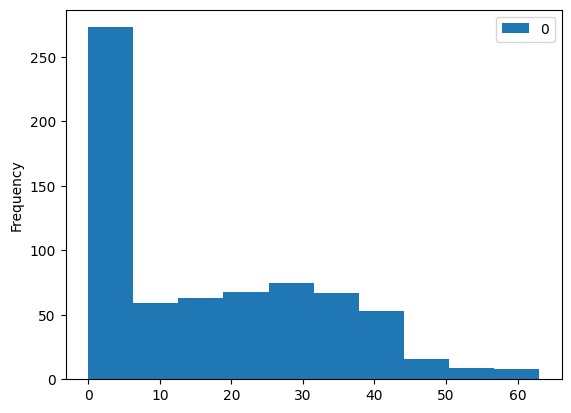

In [94]:
pd.DataFrame(desc_windows_fn.sum(1)).plot.hist()

<Axes: ylabel='Frequency'>

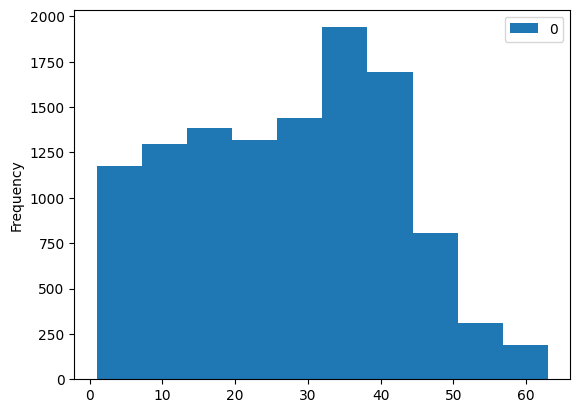

In [95]:
pd.DataFrame(desc_windows_tp.sum(1)).plot.hist()

In [97]:
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(desc_windows_fn.sum(1), desc_windows_tp.sum(1))
print("KS test statistic:", stat)
print("p-value:", p_value)

KS test statistic: 0.31065052904621454
p-value: 2.1842886044517324e-56


In [98]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(desc_windows_fn.sum(1), desc_windows_tp.sum(1))
print("Mann-Whitney U test statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U test statistic: 2397476.0
p-value: 5.796525338992638e-70


In [85]:
desc_windows_tp.sum(1).std()

np.float64(14.39108653089795)

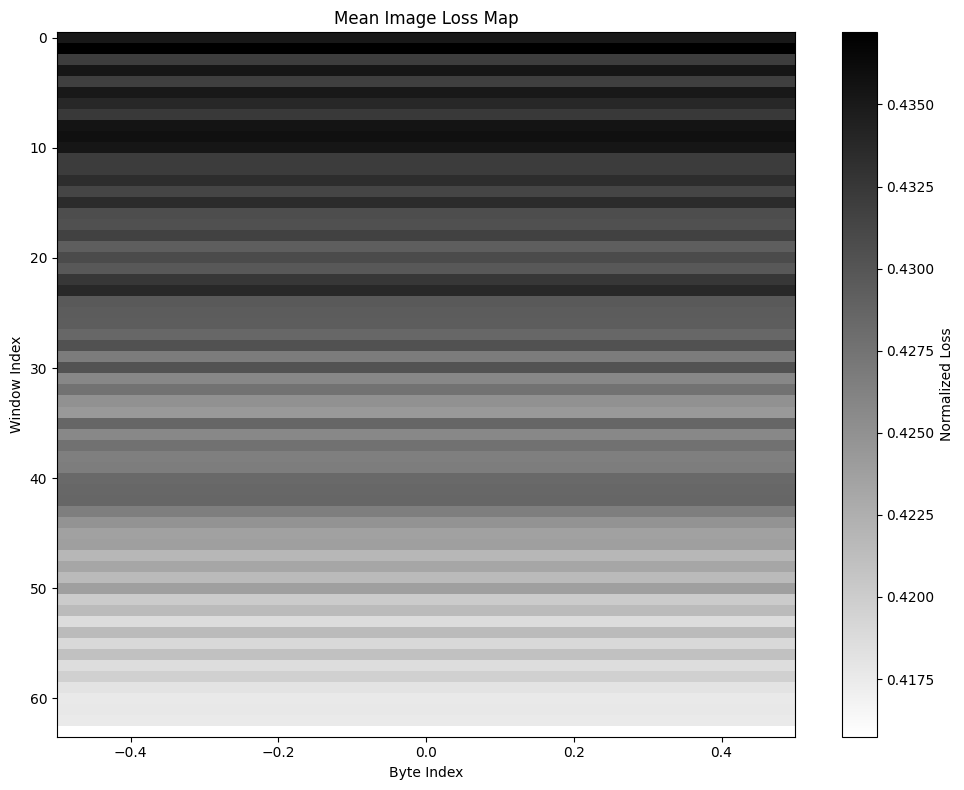

In [96]:
plot_img_loss(np.expand_dims(desc_windows_tp.mean(0), axis=1))

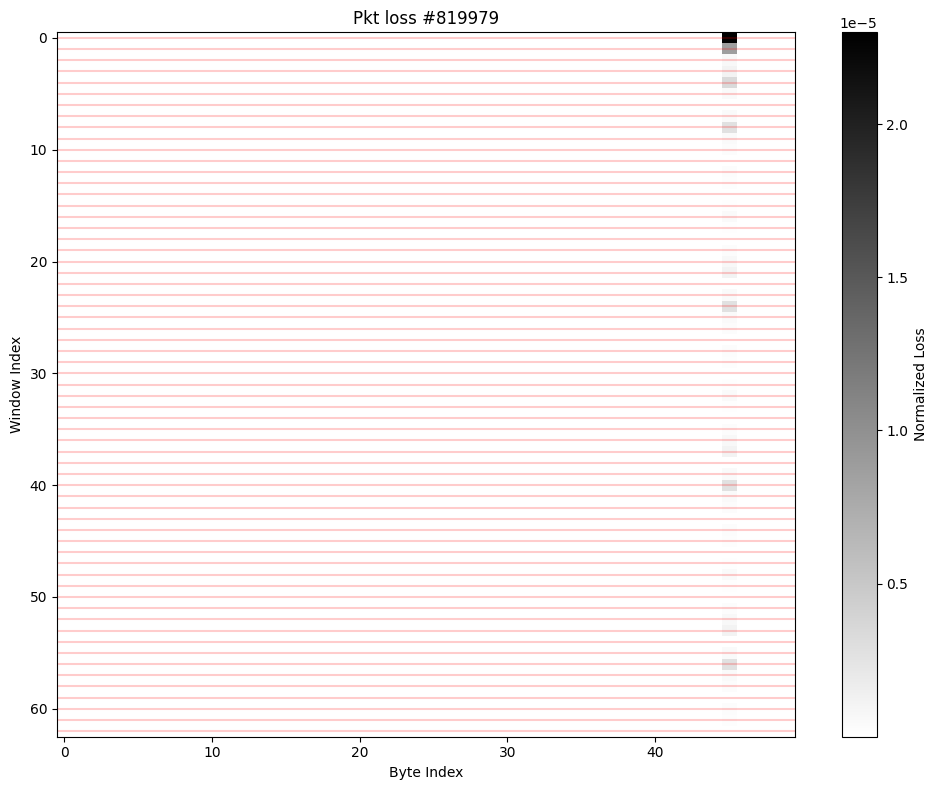

In [57]:
idx = fn[0]
plot_img_loss(y_scores[idx], targets=y_true['desc_windows'].iloc[idx][1:], name=f'Pkt loss #{y_true['start_idx'].iloc[idx]}')

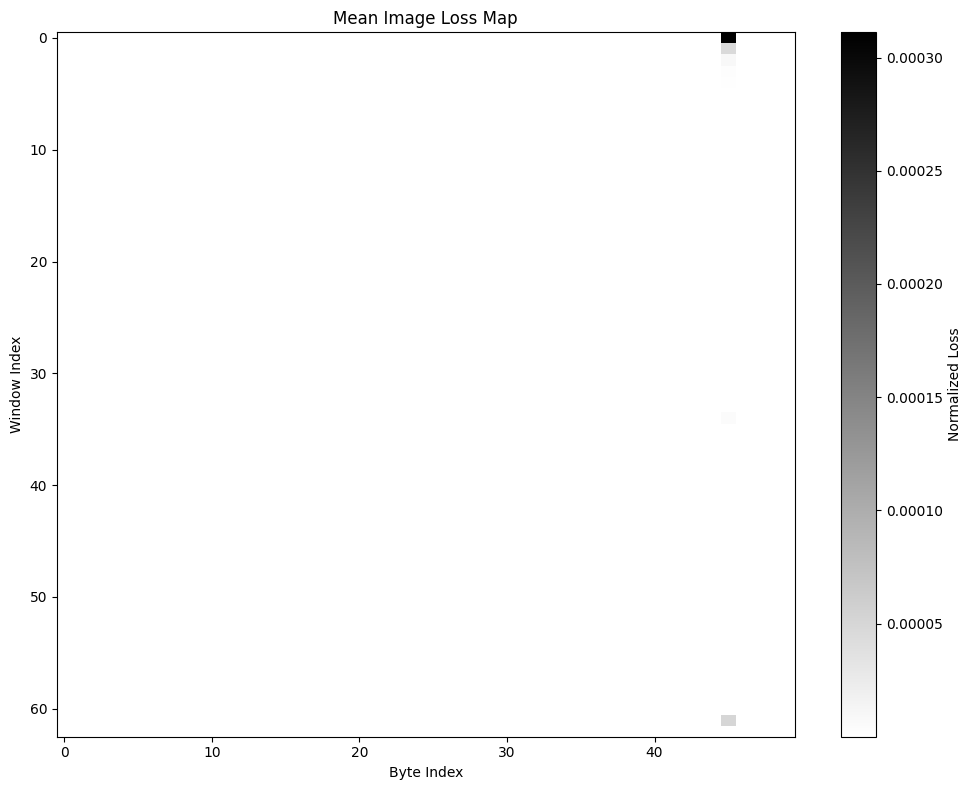

In [17]:
idx = y_true[y_true['label'] == 'Normal'].index
plot_img_loss(y_scores[fn].mean(0))

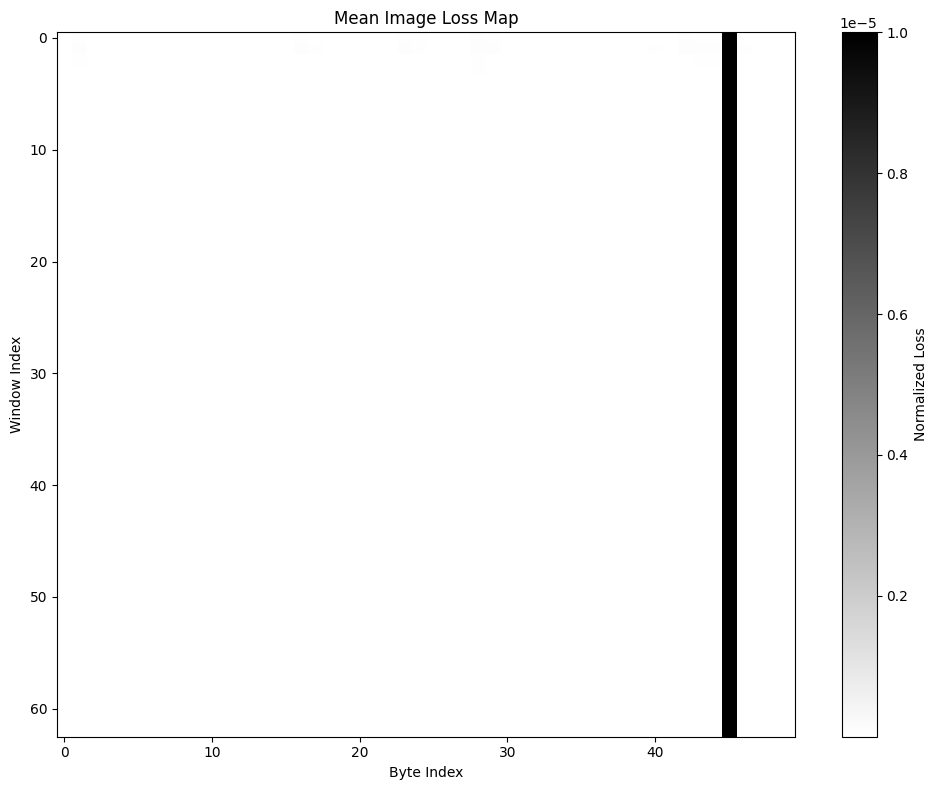

In [227]:
idx = y_true[y_true['label'] != 'Normal'].index
plot_img_loss(y_scores[idx].mean(0), max=0.00001)

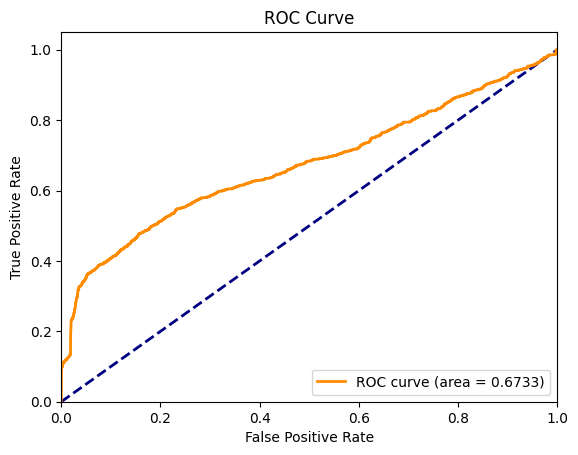

In [178]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [111]:
fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
df_val_roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr, 'thresholds':thresholds})
df_val_roc['youden-index'] = df_val_roc['tpr'] - df_val_roc['fpr']
df_val_roc.sort_values('youden-index', ascending=False).drop_duplicates('fpr')

,fpr,tpr,thresholds,youden-index
1622,0.000000,0.944005,1.091649e-06,0.944005
1623,0.063977,0.946535,9.665507e-07,0.882558
1624,0.123879,0.948821,8.304461e-07,0.824941
1625,0.184841,0.951188,3.269571e-07,0.766347
1626,0.249796,0.959432,9.690701e-08,0.709636
1627,0.310432,0.962044,5.787489e-08,0.651612
1628,0.371475,0.963840,4.087368e-08,0.592365
1629,0.430888,0.966533,3.182974e-08,0.535645
1630,0.492747,0.969798,3.148673e-08,0.477052
1631,0.553627,0.972084,2.763905e-08,0.418457


In [6]:
y_true_benign = y_true[y_true["label"] == 'Normal']

In [80]:
threshold = y_true_benign["scores"].quantile(0.9999)

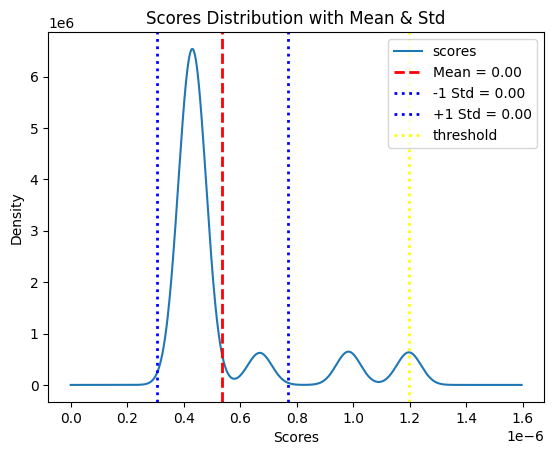

In [75]:
# Calculate mean and std
mean = y_true_benign["scores"].mean()
std = y_true_benign["scores"].std()

# Plot histogram + KDE
# y_true_benign["scores"].plot(kind="hist", bins=20, density=True, alpha=0.6, edgecolor="black")
y_true_benign["scores"].plot(kind="kde")

# Add mean line
plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")

# Add ±1 std lines
plt.axvline(mean - std, color="blue", linestyle=":", linewidth=2, label=f"-1 Std = {mean-std:.2f}")
plt.axvline(mean + std, color="blue", linestyle=":", linewidth=2, label=f"+1 Std = {mean+std:.2f}")
plt.axvline(threshold, color="yellow", linestyle=":", linewidth=2, label=f"threshold")

plt.xlabel("Scores")
plt.title("Scores Distribution with Mean & Std")
plt.legend()
plt.show()

In [81]:
tn = y_true[(y_true['scores'] < threshold) & (y_true['label'] != 'Normal')]

In [82]:
tn.shape

(327, 4)

In [84]:
tn['least_one_normal'] = tn['desc_windows'].apply(lambda x: 'Normal' in x)

/var/folders/fs/f8qz96w55l1cqqbyb70x11380000gn/T/ipykernel_23765/210102304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tn['least_one_normal'] = tn['desc_windows'].apply(lambda x: 'Normal' in x)


In [87]:
tn['least_one_normal'].head()

41     False
63     False
66     False
78      True
103    False
Name: least_one_normal, dtype: bool

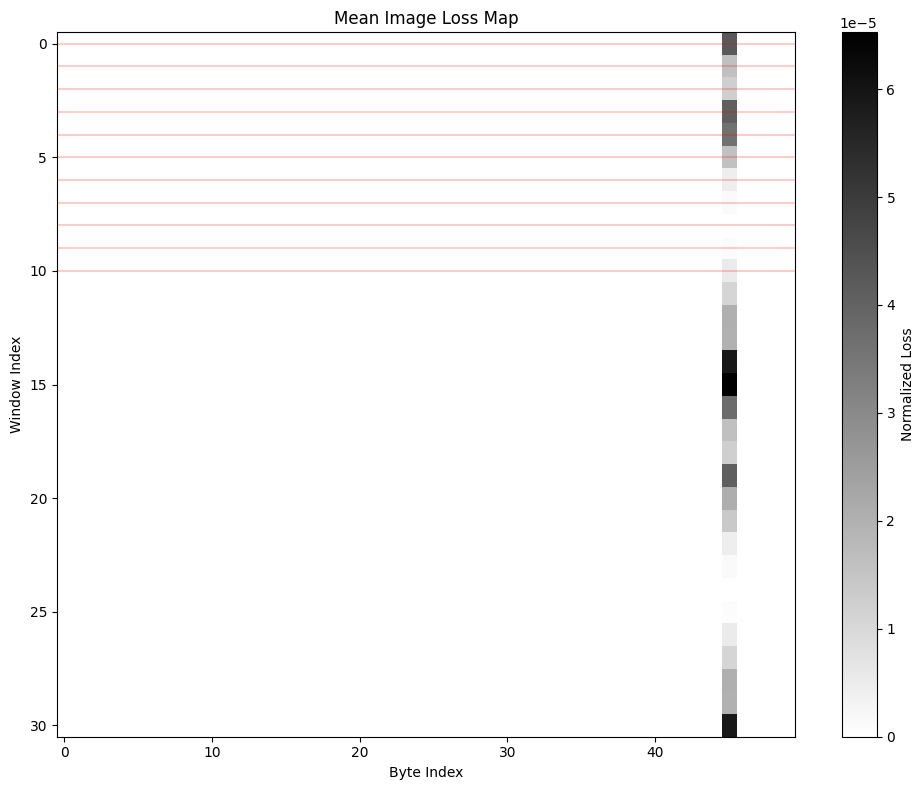

In [94]:
plot_img_loss(y_scores[tn[tn['least_one_normal'] == True].index][0], targets=tn[tn['least_one_normal'] == True]['desc_windows'].iloc[0])